# Boston House Price Prediction using XGBoost Regressor

In [14]:
# 1. Importing the dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

## 2. Dataset Loading and Initial Inspection

In [15]:
# Importing the Boston House Price Dataset
# house_price_dataset = sklearn.datasets.load_boston() # Removed due to deprecation

import requests
import io

data_url = "http://lib.stat.cmu.edu/datasets/boston"
response = requests.get(data_url)
raw_df_content = response.text

# Read the data with pandas, skipping initial rows and handling variable number of spaces
raw_df = pd.read_csv(io.StringIO(raw_df_content), sep=r"\s+", skiprows=22, header=None)

# The dataset is split across two rows per sample in the raw data
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# Loading the dataset to a Pandas DataFrame
house_price_dataframe = pd.DataFrame(data, columns=['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'])

# Add the target column (price) to the DataFrame
house_price_dataframe['price'] = target

# Print the first 5 rows of the dataframe
display(house_price_dataframe.head())

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,price
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


## 3. Exploratory Data Analysis (EDA)

In [16]:
# Checking the number of rows and columns in the dataframe
print(f"Dataset shape: {house_price_dataframe.shape}")

# Check for missing values
print("\nMissing values per column:")
print(house_price_dataframe.isnull().sum())

# Statistical measures of the dataset
print("\nStatistical summary of the dataset:")
display(house_price_dataframe.describe())

Dataset shape: (506, 14)

Missing values per column:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
price      0
dtype: int64

Statistical summary of the dataset:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,price
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


### Correlation Heatmap

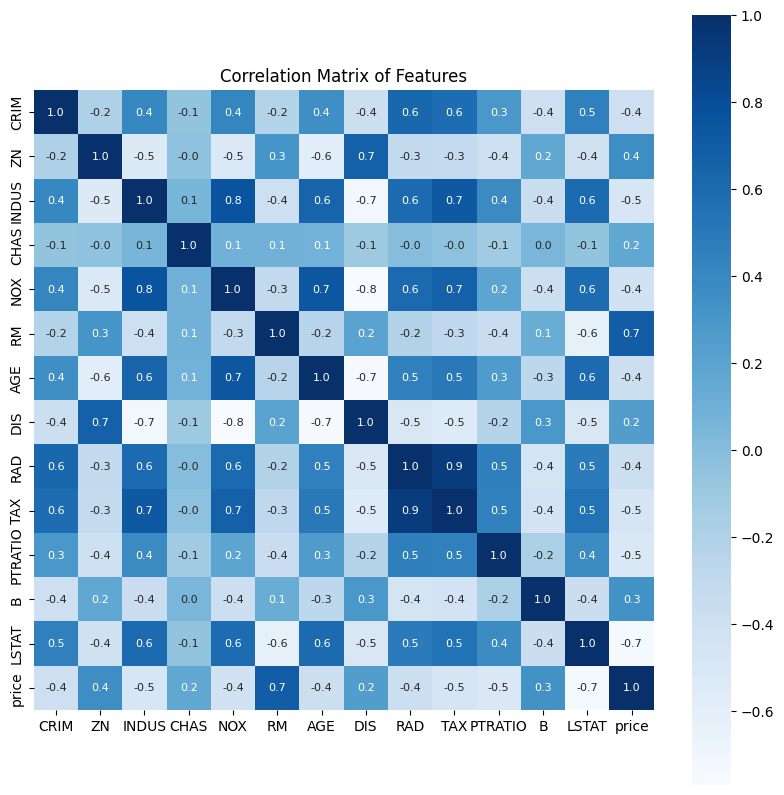

In [17]:
# Understanding the correlation between various features in the dataset
correlation = house_price_dataframe.corr()

# Constructing a heatmap to understand the correlation
plt.figure(figsize=(10,10))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8}, cmap='Blues')
plt.title('Correlation Matrix of Features')
plt.show()

## 4. Splitting Data into Training and Test Sets

In [18]:
# Splitting the data and target
X = house_price_dataframe.drop(['price'], axis=1)
Y = house_price_dataframe['price']

# Splitting the data into Training data and Test data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"Y_test shape: {Y_test.shape}")

X_train shape: (404, 13)
X_test shape: (102, 13)
Y_train shape: (404,)
Y_test shape: (102,)


## 5. Model Training - XGBoost Regressor

In [19]:
# Initialize the XGBoost Regressor model
model = XGBRegressor()

# Training the model with X_train
print("Training the XGBoost Regressor model...")
model.fit(X_train, Y_train)
print("Model training complete.")

Training the XGBoost Regressor model...
Model training complete.


## 6. Model Evaluation

In [20]:
# Prediction on training data
training_data_prediction = model.predict(X_train)

# R squared error
score_1_train = metrics.r2_score(Y_train, training_data_prediction)
# Mean Absolute Error
score_2_train = metrics.mean_absolute_error(Y_train, training_data_prediction)

print("--- Training Data Evaluation ---")
print(f"R squared error (Training) : {score_1_train:.4f}")
print(f"Mean Absolute Error (Training) : {score_2_train:.4f}")

# Prediction on test data
test_data_prediction = model.predict(X_test)

# R squared error
score_1_test = metrics.r2_score(Y_test, test_data_prediction)
# Mean Absolute Error
score_2_test = metrics.mean_absolute_error(Y_test, test_data_prediction)

print("\n--- Test Data Evaluation ---")
print(f"R squared error (Test) : {score_1_test:.4f}")
print(f"Mean Absolute Error (Test) : {score_2_test:.4f}")

--- Training Data Evaluation ---
R squared error (Training) : 1.0000
Mean Absolute Error (Training) : 0.0081

--- Test Data Evaluation ---
R squared error (Test) : 0.8771
Mean Absolute Error (Test) : 2.2488


## 7. Visualizing Actual vs. Predicted Prices

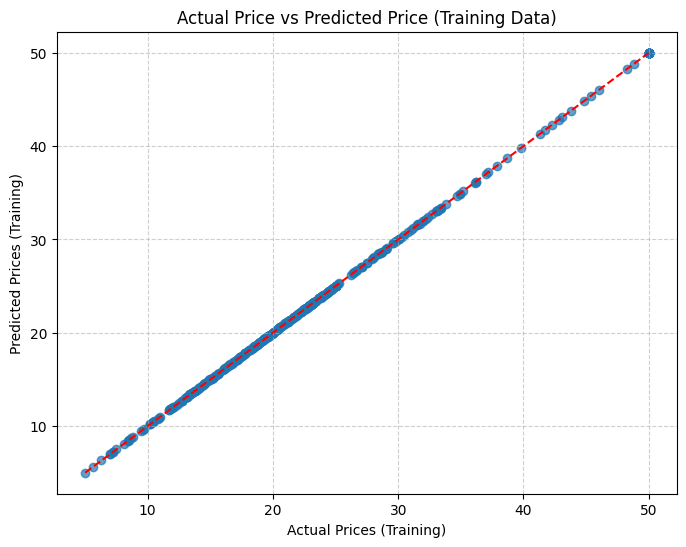

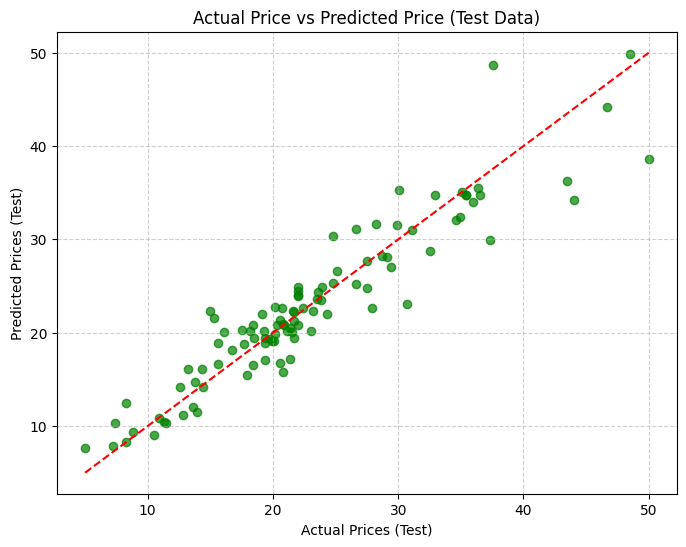

In [21]:
# Visualizing the actual prices and predicted prices for training data
plt.figure(figsize=(8,6))
plt.scatter(Y_train, training_data_prediction, alpha=0.7)
plt.xlabel("Actual Prices (Training)")
plt.ylabel("Predicted Prices (Training)")
plt.title("Actual Price vs Predicted Price (Training Data)")
plt.plot([min(Y_train), max(Y_train)], [min(Y_train), max(Y_train)], color='red', linestyle='--') # Ideal prediction line
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Visualizing the actual prices and predicted prices for test data
plt.figure(figsize=(8,6))
plt.scatter(Y_test, test_data_prediction, alpha=0.7, color='green')
plt.xlabel("Actual Prices (Test)")
plt.ylabel("Predicted Prices (Test)")
plt.title("Actual Price vs Predicted Price (Test Data)")
plt.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], color='red', linestyle='--') # Ideal prediction line
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 8. Save the Trained Model

In [22]:
import pickle

# Save the trained model to a .pkl file
filename = 'boston_house_price_model.pkl'
pickle.dump(model, open(filename, 'wb'))

print(f"Trained model saved as {filename}")

Trained model saved as boston_house_price_model.pkl
